# 栅极电离室：信号形成与模拟

α 粒子在气体中留下电离径迹，电子向阳极漂移时，在阴极和阳极上产生不同的感应信号。下面沿用原实验装置，从能量损失计算电流、电荷与前放输出，再解释两路信号的角度依赖。

建议在学完第一章和探测器信号形成后阅读。代码从本目录运行；[运行说明与数据文件](data-guide.html)。

## 1. 装置与电离径迹

实验采用背靠背 Frisch-grid ionization chamber（GIC），中央复合 α 源向两侧发射粒子；这里只讨论其中一侧。装置照片、原始波形及相关资料由张国辉课题组刘杰、崔增祺提供，实验与模型参见文献 [1]。

<figure><img src="GIC.png" alt="栅极电离室实验装置" style="max-width:600px"><figcaption>栅极电离室装置。</figcaption></figure>

<figure><img src="GIC1.png" alt="阴极、栅极和阳极的相对位置" style="max-width:620px"><figcaption>中央源、阴极、栅极与阳极。</figcaption></figure>

| 参数 | 数值 |
| --- | --- |
| 阴极—栅极距离 $D$ | 60.35 mm |
| 栅极—阳极距离 $d$ | 15.24 mm |
| 方形电极边长 | 156 mm |
| 栅丝半径 / 间距 | 0.05 mm / 2.0 mm |
| 气体 | 0.922 bar，Ar + 3.45% CO₂ |
| 阴极 / 栅极 / 阳极电位 | −1500 V / 0 V / +750 V |
| MPR-1 前放衰减时间常数 $\tau$ | 27 μs |

源含 ²³⁴U、²³⁹Pu、²³⁸Pu、²⁴⁴Cm，所用 α 能量分别为 4.775、5.155、5.499、5.805 MeV；原实验源总活度约 16 Bq，各组分约占 30%、14%、42%、14%。这里先取 5.805 MeV 的一条径迹。

电子在两个区域的漂移速度取 $v_{\rm cg}=40$ mm/μs、$v_{\rm ga}=34$ mm/μs，与 Scope8 的 GIC 设置一致。这是给定气体条件下的模型输入，不是由电压比直接推出的速度比；真实漂移速度还取决于气体成分、压强和约化电场。

### 从阻止本领得到能量沉积

阻止本领 $S(E)=-\mathrm dE/\mathrm ds$ 描述沿径迹单位长度的平均能损。把粒子能量逐步减去 $\Delta E$，每一段长度为

$$\Delta s\simeq\frac{\Delta E}{S(E-\Delta E/2)}.$$

原 SRIM 文件的阻止本领单位是 MeV/(mg/cm²)。下方三列文件已按原表中的换算因子整理为 **能量 MeV、阻止本领 MeV/mm、projected range mm**，没有改变表内数值的物理含义。

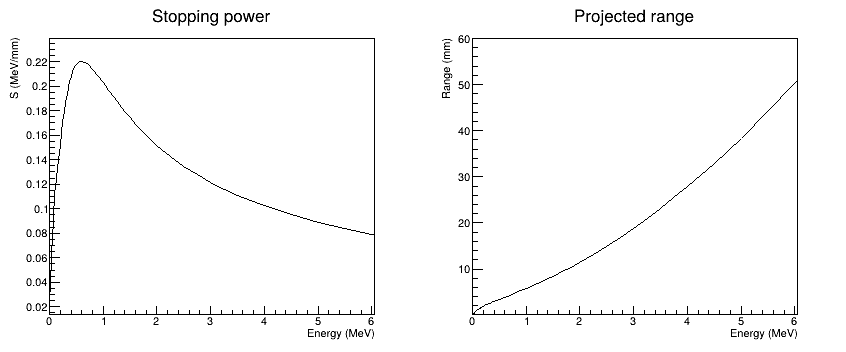

In [ ]:
gStyle->SetOptStat(0);
auto gS = new TGraph("srim_stopping.txt", "%lg %lg %*lg");
auto gR = new TGraph("srim_stopping.txt", "%lg %*lg %lg");
auto c = new TCanvas("c", "SRIM", 850, 380);
c->Divide(2, 1);
c->cd(1);
gS->SetTitle("Stopping power;Energy (MeV);S (MeV/mm)");
gS->Draw("AL");
gS->GetXaxis()->SetRangeUser(0, 6);
c->cd(2);
gR->SetTitle("Projected range;Energy (MeV);Range (mm)");
gR->Draw("AL");
gR->GetXaxis()->SetRangeUser(0, 6);
gR->SetMaximum(60);
c->Draw();

这里用阻止本领积分建立径迹上的能损分布，并把总长度缩放到 SRIM 的 projected range。这与 Scope8 的平均径迹处理一致：阻止本领积分给出路径长度估计，projected range 则包含散射对投影长度的影响，两者不应当作严格相同的量。下例不抽样射程涨落；末端低于表格下限 10 keV 的部分暂用最低能量处的阻止本领，不外推新的峰形。

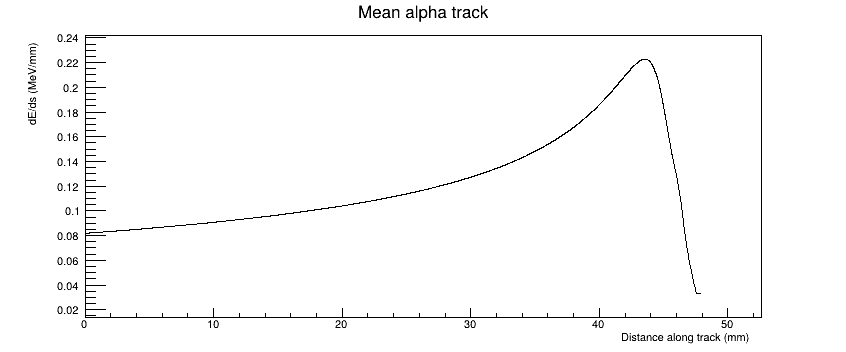

In [ ]:
double E0 = 5.805, step = 0.002;
double energy = E0, distance = 0;
std::vector<double> s, de, ds;
while (energy > 1e-10) {
    double loss = std::min(step, energy);
    double length = loss / gS->Eval(std::max(0.010, energy-loss/2));
    s.push_back(distance + length/2);
    de.push_back(loss);
    ds.push_back(length);
    distance += length;
    energy -= loss;
}
double scale = gR->Eval(E0) / distance;
auto bragg = new TGraph();
for (int j=0; j<(int)s.size(); ++j) {
    s[j] *= scale;
    bragg->SetPoint(j, s[j], de[j]/(ds[j]*scale));
}
std::cout << std::fixed << std::setprecision(3)
          << "E = " << std::accumulate(de.begin(),de.end(),0.0)
          << " MeV; projected range = " << gR->Eval(E0) << " mm\n";
c->Clear();
bragg->SetTitle("Mean alpha track;Distance along track (mm);dE/ds (MeV/mm)");
bragg->Draw("AL");
c->Draw();

粒子减速时单位长度能损增大，形成 Bragg peak；更低能区中阻止本领又下降。产生的电子—离子对数约为 $N_e=\Delta E/W$，$W$ 是产生一个可收集电子—离子对所需的平均能量，不是原子的电离能。

## 2. 从漂移到感应电流

### 栅极的作用

普通平行板电离室在电子收集的时间尺度内，信号会依赖电离发生的位置。Frisch 栅极把漂移区与阳极收集区隔开：理想情况下，电子过栅前几乎不产生阳极信号，过栅后才在阳极—栅极间形成感应电流。因此阳极主要给出能量信息，阴极还保留径迹的位置信息。

Shockley–Ramo 定理写为

$$i_k=q\,\mathbf v\cdot\mathbf E_{w,k},\qquad
\mathbf E_{w,k}=-\nabla\phi_{w,k}.$$

权重势 $\phi_{w,k}$ 来自一个辅助静电问题：读出电极置于单位电势，其他电极接地，并移走漂移电荷。**工作电场决定电子怎样运动，权重场决定这段运动在电极上感应多少信号。** 两者不能混用。

理想栅极下，阴极权重势在漂移区为 $1-z/D$，阳极权重势在该区近似为零；收集区的阳极权重势为 $(z-D)/d$。下面用正值表示两路电子感应电流的大小，输出电压的正负由前放极性另外给出。慢正离子信号不在这个快速电子读出的模型中。

### 电子到栅与到阳极的时刻

设源在阴极 $z=0$，径迹与漂移方向夹角为 $\theta$。第 $j$ 段位于 $z_j=s_j\cos\theta$，则

$$t_{g,j}=\frac{D-s_j\cos\theta}{v_{\rm cg}},\qquad
t_{a,j}=t_{g,j}+\frac{d}{v_{\rm ga}}.$$

<figure><img src="drift.png" alt="径迹及电子漂移距离" style="max-width:560px"><figcaption>同一条径迹上的电子具有不同的到栅时刻。</figcaption></figure>

一小段电荷在漂移区贡献一个近似矩形的阴极电流，过栅后贡献一个阳极电流：

$$i_{c,j}=\frac{e}{W}\Delta E_j\frac{v_{\rm cg}}{D}
\quad(0<t<t_{g,j}),$$
$$i_{a,j}=\frac{e}{W}\Delta E_j\frac{v_{\rm ga}}{d}
\quad(t_{g,j}<t<t_{a,j}).$$

把各段相加即可。为直接对应能量，这里省略共同因子 $e/W$，使用 **MeV/μs 的能量等效电流**，积分后为 MeV-equivalent，不是安培和库仑。若取 $W=26$ eV，1 MeV-equivalent 对应约 6.16 fC。

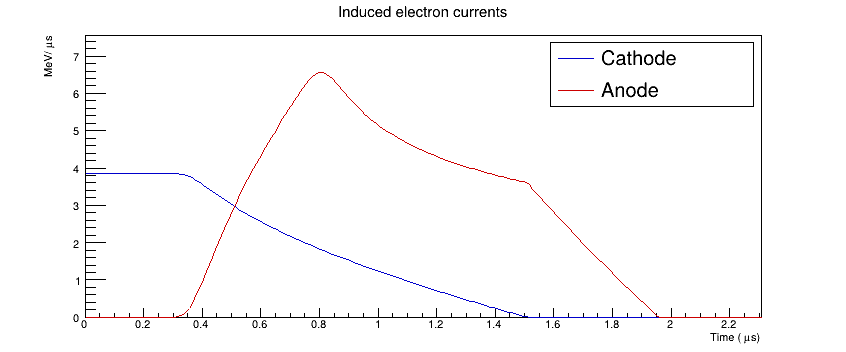

In [ ]:
double D=60.35, d=15.24, vc=40.0, va=34.0;
double theta=0.0;                   // degree；改为 45 或 90 可比较径迹方向
const int n=5000;
double dt=0.01, t[n], ic[n]={0}, ia[n]={0};
for (int k=0; k<n; ++k) t[k]=(k+0.5)*dt;
for (int j=0; j<(int)s.size(); ++j) {
    double tg=(D-s[j]*std::cos(theta*TMath::DegToRad()))/vc;
    double ta=tg+d/va;
    for (int k=0; k<(int)std::ceil(tg/dt); ++k) {
        double overlap=std::max(0.0,std::min((k+1)*dt,tg)-k*dt);
        ic[k] += de[j]*vc/D*overlap/dt;
    }
    for (int k=int(tg/dt); k<(int)std::ceil(ta/dt); ++k) {
        double overlap=std::max(0.0,std::min((k+1)*dt,ta)-std::max(k*dt,tg));
        ia[k] += de[j]*va/d*overlap/dt;
    }
}
auto gic=new TGraph(n,t,ic);
auto gia=new TGraph(n,t,ia);
c->Clear();
gic->SetTitle("Induced electron currents;Time (#mus);MeV/#mus");
gic->SetLineColor(kBlue+1); gia->SetLineColor(kRed+1);
gic->Draw("AL"); gic->GetXaxis()->SetRangeUser(0,2.3);
gic->SetMaximum(1.15*std::max(*std::max_element(ic,ic+n),*std::max_element(ia,ia+n)));
gia->Draw("L SAME");
auto legend=new TLegend(.65,.7,.89,.88);
legend->AddEntry(gic,"Cathode","l"); legend->AddEntry(gia,"Anode","l");
legend->Draw(); c->Draw();

`overlap` 是一段电流与当前采样时间段重叠的长度。这样处理边界，电子到栅时刻就不必恰好落在采样点上。Scope8 用 1 ns 计算探测器电流；这里用 10 ns 的平均电流展示相同的信号形成过程。

## 3. 积分电荷与前放输出

积分电流得到感应电荷。理想情况下，每一段电子都走过完整的栅极—阳极距离，因此

$$Q_a=\sum_j\Delta E_j=E_0,\qquad
Q_c=\sum_j\Delta E_j\left(1-\frac{s_j\cos\theta}{D}\right).$$

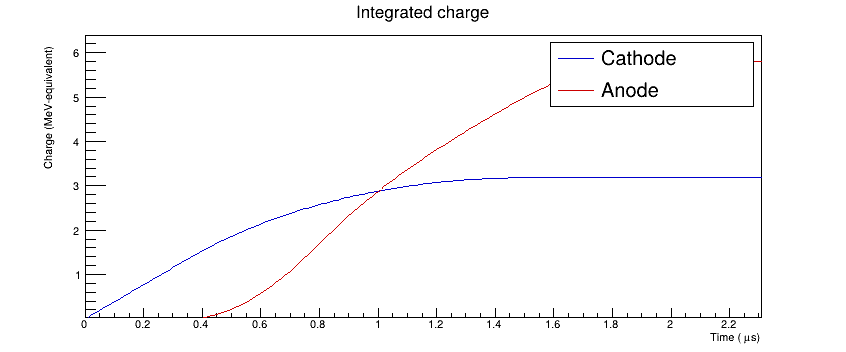

In [ ]:
double qc[n]={0}, qa[n]={0}, te[n];
double sumc=0, suma=0;
for (int k=0; k<n; ++k) {
    sumc += ic[k]*dt; suma += ia[k]*dt;
    qc[k]=sumc; qa[k]=suma; te[k]=(k+1)*dt;
}
auto gqc=new TGraph(n,te,qc); auto gqa=new TGraph(n,te,qa);
c->Clear();
gqc->SetTitle("Integrated charge;Time (#mus);Charge (MeV-equivalent)");
gqc->SetLineColor(kBlue+1); gqa->SetLineColor(kRed+1);
gqc->Draw("AL"); gqc->GetXaxis()->SetRangeUser(0,2.3);
gqc->SetMaximum(E0*1.1); gqa->Draw("L SAME"); legend->Draw(); c->Draw();
std::cout << std::setprecision(6) << "Qa = " << qa[n-1]
          << "; Qc = " << qc[n-1] << " MeV-equivalent\n";
if (std::abs(qa[n-1]-E0)>1e-8) throw std::runtime_error("Charge integral failed");

电荷灵敏前放的反馈电容 $C_f$ 与电阻 $R_f$ 给出 $\tau=R_fC_f$，输出为

$$V(t)=-\frac{1}{C_f}\int_0^t i(t')e^{-(t-t')/\tau}\,\mathrm dt'.$$

在能量等效单位下，把电荷转换和放大系数写成 $G$。对一小段近似恒定的输入电流，可用递推式代替重复计算卷积：

$$u_k=e^{-\Delta t/\tau}u_{k-1}
+\tau\bigl(1-e^{-\Delta t/\tau}\bigr)i_k,\qquad V_k=G u_k.$$

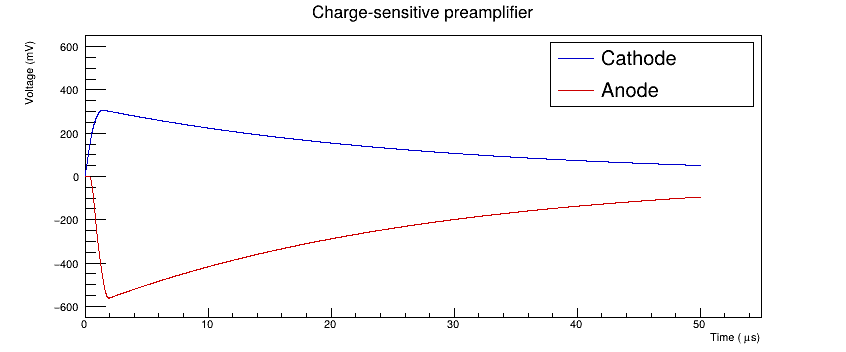

In [ ]:
double tau=27.0, a=std::exp(-dt/tau);
double uc[n], ua[n], vcOut[n], vaOut[n], state_c=0, state_a=0;
for (int k=0; k<n; ++k) {
    state_c=a*state_c+tau*(1-a)*ic[k];
    state_a=a*state_a+tau*(1-a)*ia[k];
    uc[k]=state_c; ua[k]=state_a;
    vcOut[k]=100*uc[k]; vaOut[k]=-100*ua[k];
}
auto guc=new TGraph(n,te,vcOut); auto gua=new TGraph(n,te,vaOut);
c->Clear();
guc->SetTitle("Charge-sensitive preamplifier;Time (#mus);Voltage (mV)");
guc->SetLineColor(kBlue+1); gua->SetLineColor(kRed+1);
guc->Draw("AL"); guc->SetMinimum(-650); guc->SetMaximum(650);
gua->Draw("L SAME"); legend->Draw(); c->Draw();
std::cout << "Anode peak / Qa = " << *std::max_element(ua,ua+n)/qa[n-1] << "\n";

收集电荷需要时间，而前放在此期间已经衰减，所以峰高小于瞬时输入同样电荷时的幅度，这就是 ballistic deficit。改变径迹角度会改变电荷到达的时间分布，即使 $Q_a$ 不变，前放峰高也可能改变。后面的实验分析会比较峰高与经过 pole-zero correction 的电荷估计。

<a id="angle"></a>

## 4. 角度依赖与阴极—阳极关联

当 $\theta=90^\circ$ 时，径迹与阴极平行，各段电子几乎同时到栅，阴极与阳极电流都接近矩形；当 $\theta=0^\circ$ 时，电子到栅时刻沿径迹展开，电流边缘反映了能损分布。两者可以通过修改上方 `theta` 比较。

令电离能量的重心为 $\bar s=\sum_j s_j\Delta E_j/E_0$，则

$$Q_c(E_0,\theta)=E_0\left(1-\frac{\bar s}{D}\cos\theta\right)
=E_0-[E_0-Q_c(E_0,0)]\cos\theta.$$

这不是只由几何长度决定的关系：Bragg peak 使电离重心偏向径迹末端。知道 $E_0=Q_a$ 并由该能量的径迹求得 $\bar s$ 后，才可用 $Q_c/Q_a$ 估计角度。

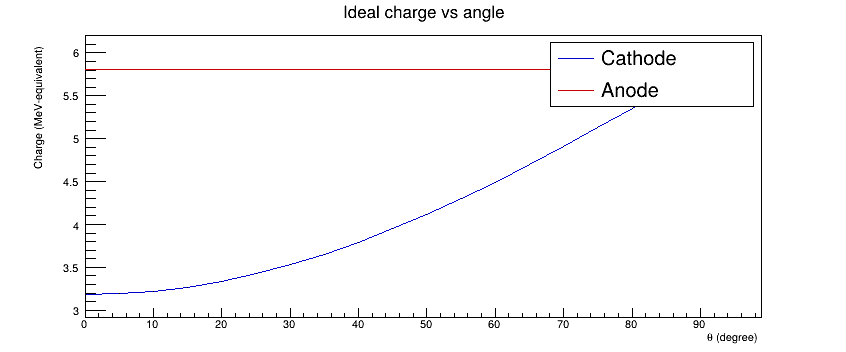

In [ ]:
double centroid=0;
for (int j=0; j<(int)s.size(); ++j) centroid+=s[j]*de[j]/E0;
auto gc=new TGraph(); auto ga=new TGraph();
for (int j=0; j<19; ++j) {
    double angle=5.0*j;
    gc->SetPoint(j,angle,E0*(1-centroid/D*std::cos(angle*TMath::DegToRad())));
    ga->SetPoint(j,angle,E0);
}
c->Clear();
gc->SetTitle("Ideal charge vs angle;#theta (degree);Charge (MeV-equivalent)");
gc->SetLineColor(kBlue+1); ga->SetLineColor(kRed+1);
gc->Draw("ALP"); gc->SetMaximum(6.2); ga->Draw("L SAME");
legend->Draw(); c->Draw();
std::cout << "Ionization centroid = " << centroid << " mm\n";

### 比较两种极限方向的电压波形

对 $90^\circ$ 径迹，全部电子在 $D/v_{\rm cg}$ 到栅，可以直接用矩形电流算出前放响应。下图与前面 $0^\circ$ 的结果使用相同增益，保留幅度差异；为了比较形状，阳极也暂画成正极性。

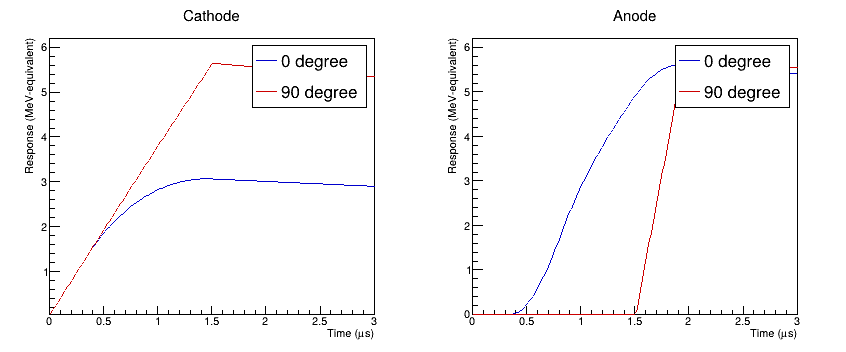

In [ ]:
double tg90=D/vc, uc90[n], ua90[n], sc=0, sa=0;
for (int k=0; k<n; ++k) {
    double left=te[k]-dt;
    double ci90=E0*vc/D*std::max(0.0,std::min(1.0,(tg90-left)/dt));
    double ai90=E0*va/d*std::max(0.0,std::min(te[k],tg90+d/va)-std::max(left,tg90))/dt;
    sc=a*sc+tau*(1-a)*ci90; sa=a*sa+tau*(1-a)*ai90;
    uc90[k]=sc; ua90[k]=sa;
}
c->Clear(); c->Divide(2,1);
double* zero[2]={uc,ua}; double* ninety[2]={uc90,ua90};
const char* labels[2]={"Cathode","Anode"};
for (int j=0; j<2; ++j) {
    c->cd(j+1);
    auto g0=new TGraph(n,te,zero[j]); auto g90=new TGraph(n,te,ninety[j]);
    g0->SetTitle(Form("%s;Time (#mus);Response (MeV-equivalent)",labels[j]));
    g0->SetLineColor(kBlue+1); g90->SetLineColor(kRed+1);
    g0->Draw("AL"); g0->GetXaxis()->SetRangeUser(0,3); g0->SetMaximum(6.2);
    g90->Draw("L SAME");
    auto lg=new TLegend(.6,.7,.88,.88);
    lg->AddEntry(g0,"0 degree","l"); lg->AddEntry(g90,"90 degree","l"); lg->Draw();
}
c->Draw();
std::ofstream templates("gic_templates.txt");
templates << std::setprecision(17);
for (int k=0; k<n; ++k)
    templates << te[k] << " " << uc[k] << " " << ua[k] << " " << uc90[k] << " " << ua90[k] << "\n";
templates.close();

### Scope8 的逐事件结果

下面读取 Scope8 的 30,000 个 GIC 模拟事件，只保留原文件的能量、角度、径迹长度和积分电荷等标量分支。它包含四组 α 能量与径迹涨落，没有叠加电子学噪声或人为的能量展宽。

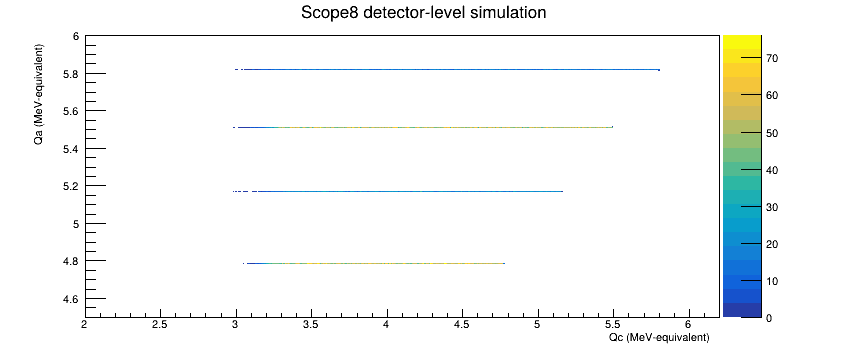

In [ ]:
auto f=TFile::Open("scope8_gic_observables.root");
auto tree=f->Get<TTree>("ChargeEvents");
std::cout << "Scope8 detector events: " << tree->GetEntries() << "\n";
c->Clear();
tree->Draw("anode_charge_mev:cathode_charge_mev>>h(450,2,6.2,400,4.5,6)","","COLZ");
auto h=(TH2D*)gDirectory->Get("h");
h->SetTitle("Scope8 detector-level simulation;Qc (MeV-equivalent);Qa (MeV-equivalent)");
c->SetRightMargin(.15); c->Draw();

每一条横带对应一种 α 能量；同一能量下，阴极电荷随角度变化，阳极电荷保持近似不变。原模拟的离散时间积分也会带来细小带宽，不能把它当作探测器分辨率。真实实验中要先处理电子学响应，再与这种关系比较，不能把前放峰高直接称为积分电荷。

### 保存波形

将当前计算结果保存为一条 `TTree` 记录，后续可对不同能量、角度逐事件 `Fill()`。`theta` 的单位是 degree，`ic/ia` 为 MeV/μs，`uc/ua` 为正值的能量等效前放响应；对应时间点由 `dt` 和数组索引确定。

In [ ]:
TFile out("gic_example.root","RECREATE");
TTree wave("wave","One ideal GIC pulse");
wave.Branch("e",&E0,"e/D");
wave.Branch("theta",&theta,"theta/D");
wave.Branch("dt",&dt,"dt/D");
wave.Branch("ic",ic,"ic[5000]/D"); wave.Branch("ia",ia,"ia[5000]/D");
wave.Branch("uc",uc,"uc[5000]/D"); wave.Branch("ua",ua,"ua[5000]/D");
wave.Fill(); wave.Write(); out.Close();
std::cout << "Saved gic_example.root: wave, 1 event, 5000 samples/channel\n";

## 5. 实际信号还受什么影响

理想模型解释了主要形状，但实际 GIC 的本底与脉冲差异不能归结为单一效应。

- **电子附着**：杂质使漂移电子减少，可用 $N_e(t)=N_e(0)e^{-t/\tau_{\rm att}}$ 描述简单情况。长距离漂移损失更多，阳极电荷也会出现角度依赖。
- **有限栅极屏蔽**：阳极在电子过栅前可能已有感应分量。栅极非屏蔽与电子穿过栅丝的透明度不是同一件事，不能只用一个几何开孔比例修正全部信号。
- **输运与电子学**：扩散、射程涨落、前放带宽和数字滤波会改变边缘与上升时间。前放峰高的角度依赖既可能来自附着，也可能来自 ballistic deficit；应结合电荷和波形判断。

下一节：[实验波形分析与模拟比较](Experimental_Data_Analysis.html)。

## 参考文献

1. J. Liu et al., “The impacts of the ballistic deficit and electron attachment on the pulse shapes of the Frisch-grid ionization chamber,” *Nucl. Instrum. Methods A* **1014**, 165751 (2021). [DOI](https://doi.org/10.1016/j.nima.2021.165751).
2. A. Göök et al., “Application of the Shockley–Ramo theorem on the grid inefficiency of Frisch grid ionization chambers,” *Nucl. Instrum. Methods A* **664**, 289–293 (2012). [DOI](https://doi.org/10.1016/j.nima.2011.10.052).
3. J. F. Ziegler, M. D. Ziegler and J. P. Biersack, “SRIM – The stopping and range of ions in matter (2010),” *Nucl. Instrum. Methods B* **268**, 1818–1823 (2010). [DOI](https://doi.org/10.1016/j.nimb.2010.02.091).